## Úloha 3

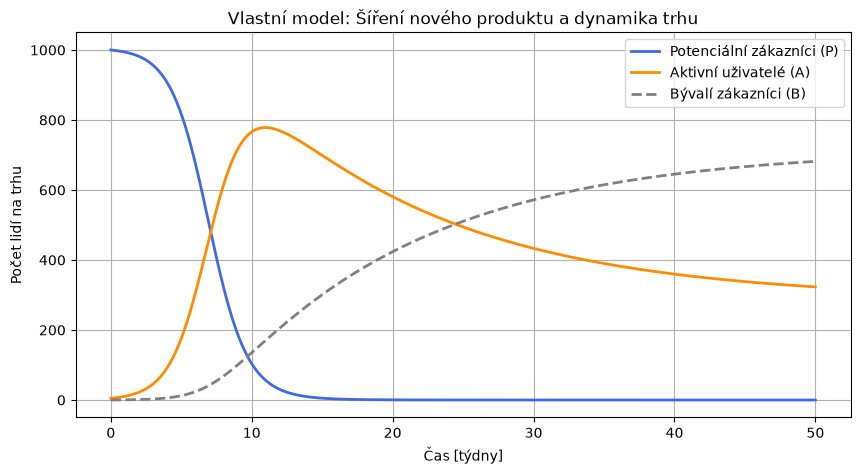

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Definice diferenciálních rovnic modelu adaptace produktu
def trzni_model(stav, t, alpha, beta, zeta):
    P, A, B = stav
    dPdt = -alpha * P * A
    dAdt = (alpha * P * A) + (zeta * B) - (beta * A)
    dBdt = (beta * A) - (zeta * B)
    
    return [dPdt, dAdt, dBdt]

casova_osa = np.linspace(0, 50, 1000)  
pocatecni_stav = [1000, 5, 0]         

# Koeficienty
mira_doporuceni_alpha = 0.0008  
mira_odchodu_beta = 0.05        
mira_navratu_zeta = 0.02        

vysledek = odeint(trzni_model, pocatecni_stav, casova_osa, 
                  args=(mira_doporuceni_alpha, mira_odchodu_beta, mira_navratu_zeta))

P = vysledek[:, 0]
A = vysledek[:, 1]
B = vysledek[:, 2]

plt.figure(figsize=(10, 5))
plt.plot(casova_osa, P, label='Potenciální zákazníci (P)', color='royalblue', lw=2)
plt.plot(casova_osa, A, label='Aktivní uživatelé (A)', color='darkorange', lw=2)
plt.plot(casova_osa, B, label='Bývalí zákazníci (B)', color='gray', linestyle='--', lw=2)

plt.title("Vlastní model: Šíření nového produktu a dynamika trhu")
plt.xlabel("Čas [týdny]")
plt.ylabel("Počet lidí na trhu")
plt.legend()
plt.grid(True)
plt.show()